# E-Commerce Sales Optimization Project

**Objective**: Analyze sales data to optimize promotions, identify product segments, and provide actionable business recommendations.

**Dataset**: 20,252 products with features like price, sales volume, promotion, season, material, etc.

**Tools Used**: Python (pandas, seaborn, matplotlib, scipy, sklearn), Power BI for dashboard.

**Team**: Mohamed Saad , Mohamed Osama , Shahd Khaled , Malak Yasser  

## 1. Imports and Setup

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
%matplotlib inline

## 2. Data Loading and Initial Exploration

In [60]:
df=pd.read_csv('Business_sales_EDA.csv',sep=";")

In [61]:
df.head(7)

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China
5,117590,End-cap,Yes,clothing,Yes,1282,Zara,https://www.zara.com/us/en/contrasting-collar-...,CONTRASTING COLLAR JACKET,Relaxed fit jacket. Contrasting lapel collar a...,25.95,USD,jackets,WOMAN,Autumn,Cotton,Turkey
6,189118,Front of Store,No,clothing,No,688,Zara,https://www.zara.com/us/en/faux-leather-puffer...,FAUX LEATHER PUFFER JACKET,Faux leather puffer jacket. High collar and lo...,87.99,USD,jackets,MAN,Winter,Acrylic,China


In [62]:
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='object')

In [63]:
df.shape

(20252, 17)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  object 
 2   Promotion         20252 non-null  object 
 3   Product Category  20252 non-null  object 
 4   Seasonal          20252 non-null  object 
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

In [65]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product ID,20252.0,NaN,NaN,NaN,208931.432303,8961.076507,110075.0,204442.75,209505.5,214568.25,219631.0
Product Position,20252,3,Aisle,7810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Promotion,20252,2,No,11812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product Category,20252,1,clothing,20252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seasonal,20252,2,No,10136,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales Volume,20252.0,NaN,NaN,NaN,1097.400454,298.234609,518.0,849.0,990.0,1364.25,1940.0
brand,20252,1,Zara,20252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,20252,228,https://www.zara.com/us/en/knit-sweater-with-r...,187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,20251,17215,PLAID OVERSHIRT,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,20250,221,Varsity jacket with elastic collar and long sl...,333,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Wrangling 

In [66]:
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                1
description         2
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [67]:
df.dropna(inplace=True)

In [68]:
df.isnull().sum()

Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
name                0
description         0
price               0
currency            0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [69]:
df.duplicated().sum()

0

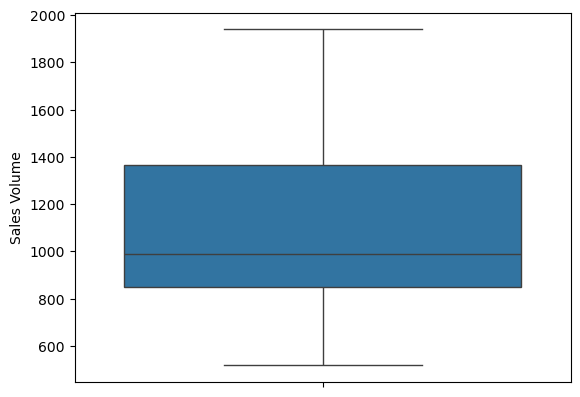

In [70]:
sns.boxplot(data=df["Sales Volume"])
plt.show()

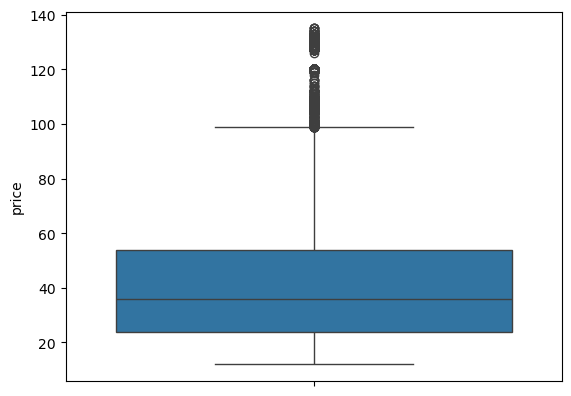

In [71]:
sns.boxplot(data=df["price"])
plt.show()

In [72]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

In [73]:
outliers_SalesVolume, lower_SalesVolume, upper_SalesVolume = detect_outliers_iqr(df, "Sales Volume")
outliers_price, lower_price, upper_price = detect_outliers_iqr(df, "price")

print("Outliers in Sales Volume:", len(outliers_SalesVolume))
print("Outliers in price:", len(outliers_price))

Outliers in Sales Volume: 0
Outliers in price: 641


In [74]:
df['price'] = df['price'].clip(lower_price, upper_price)

In [75]:
obj_columns = ['Product Position', 'Promotion', 'Product Category', 'Seasonal','brand', 'name', 'description', 'terms', 'section','season', 'material', 'origin']

In [76]:
for col in obj_columns:
    df[col] = df[col].astype(str).str.lower().str.strip()

In [77]:
df['material'].unique()

array(['polyester', 'cotton', 'wool blend', 'acrylic', 'wool', 'viscose',
       'linen', 'denim', 'linen blend', 'satin', 'silk'], dtype=object)

In [78]:
df['season'].unique()

array(['winter', 'autumn', 'spring', 'summer'], dtype=object)

## 4. Exploratory Data Analysis (EDA)

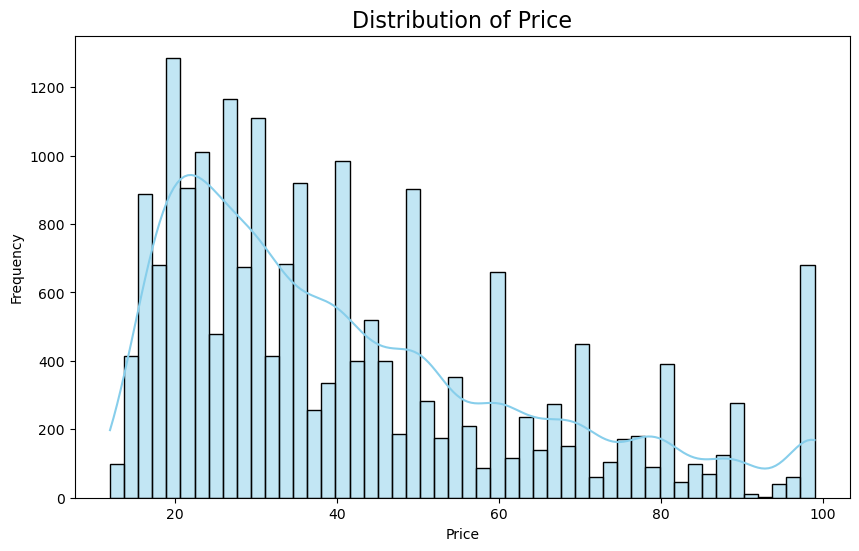

In [79]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='price', bins=50, kde=True, color='skyblue')
plt.title('Distribution of Price', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

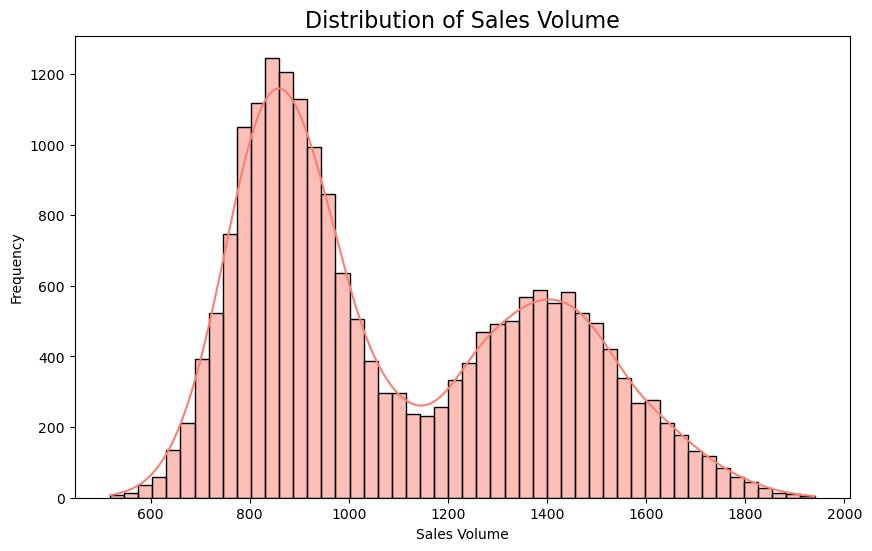

In [80]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Sales Volume', bins=50, kde=True, color='salmon')
plt.title('Distribution of Sales Volume', fontsize=16)
plt.xlabel('Sales Volume')
plt.ylabel('Frequency')
plt.show()

In [81]:
df['material'].value_counts()

material
cotton         3850
wool           3805
wool blend     3373
polyester      2774
linen          2573
denim          1027
viscose         990
acrylic         881
linen blend     807
satin           132
silk             38
Name: count, dtype: int64

C:\Users\maham\AppData\Local\Temp\ipykernel_44612\108856192.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




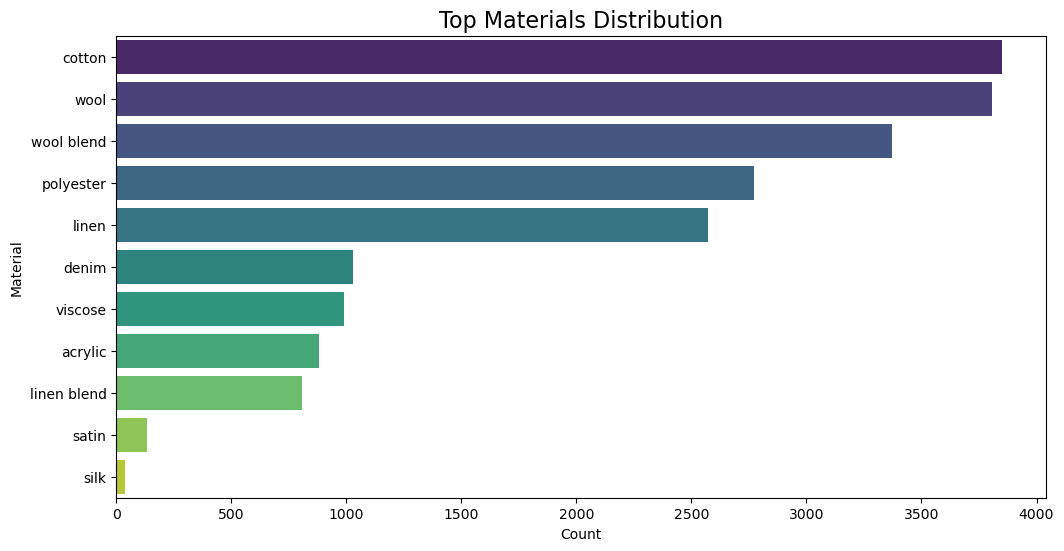

In [82]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df['material'].value_counts().values, y=df['material'].value_counts().index, palette='viridis')
plt.title('Top Materials Distribution', fontsize=16)
plt.xlabel('Count')
plt.ylabel('Material')
plt.show()


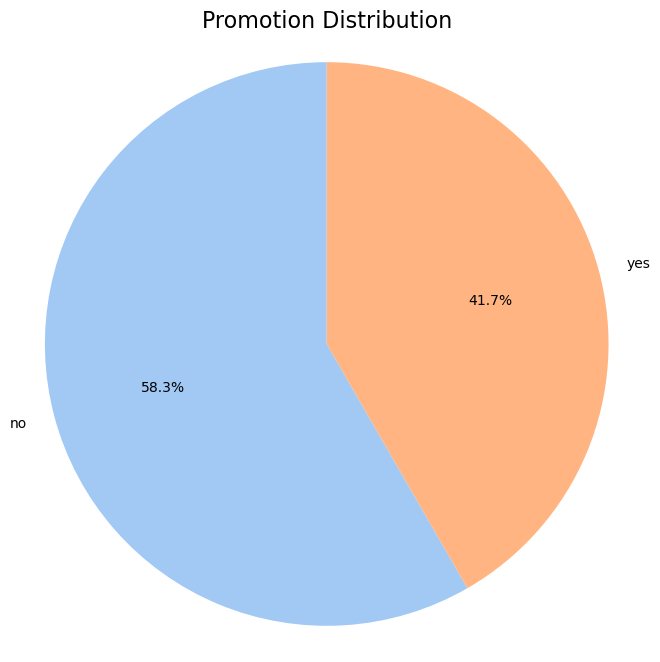

In [83]:
plt.figure(figsize=(8, 8))
plt.pie(df['Promotion'].value_counts(), labels=df['Promotion'].value_counts().index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Promotion Distribution', fontsize=16)
plt.axis('equal')  
plt.show()

C:\Users\maham\AppData\Local\Temp\ipykernel_44612\2489849182.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




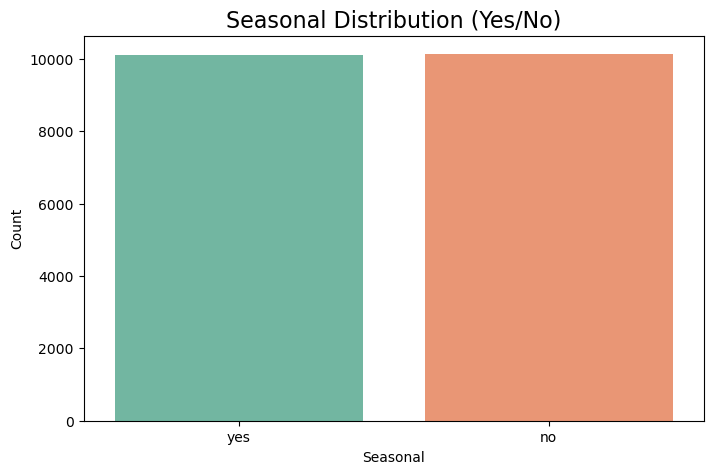

In [84]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Seasonal', palette='Set2')
plt.title('Seasonal Distribution (Yes/No)', fontsize=16)
plt.xlabel('Seasonal')
plt.ylabel('Count')
plt.show()

C:\Users\maham\AppData\Local\Temp\ipykernel_44612\902076331.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




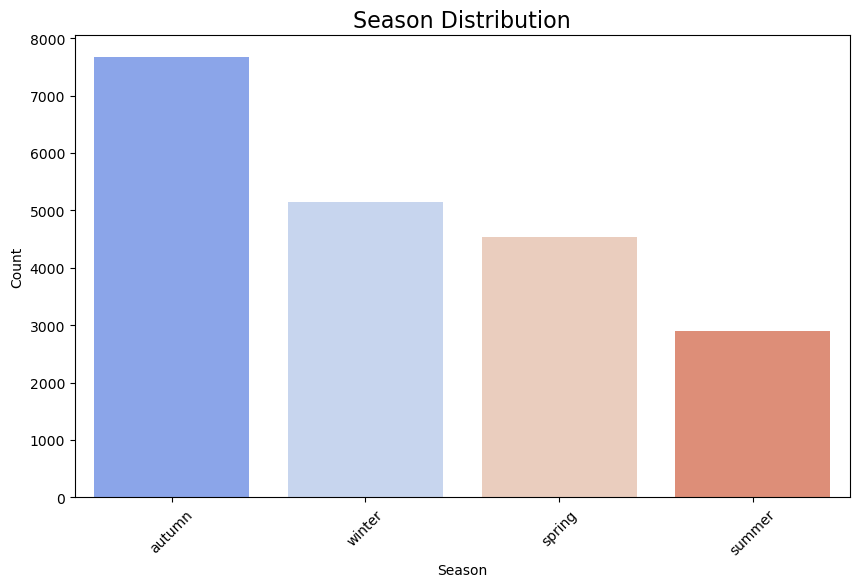

In [85]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='season', palette='coolwarm', order=df['season'].value_counts().index)
plt.title('Season Distribution', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [86]:
df['revenue'] = df['price'] * df['Sales Volume']

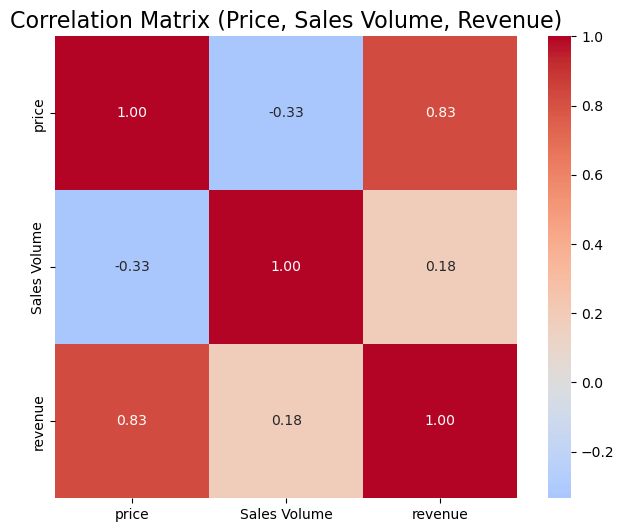

In [87]:
plt.figure(figsize=(8, 6))
corr = df[['price', 'Sales Volume', 'revenue']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Matrix (Price, Sales Volume, Revenue)', fontsize=16)
plt.show()


C:\Users\maham\AppData\Local\Temp\ipykernel_44612\3206825615.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




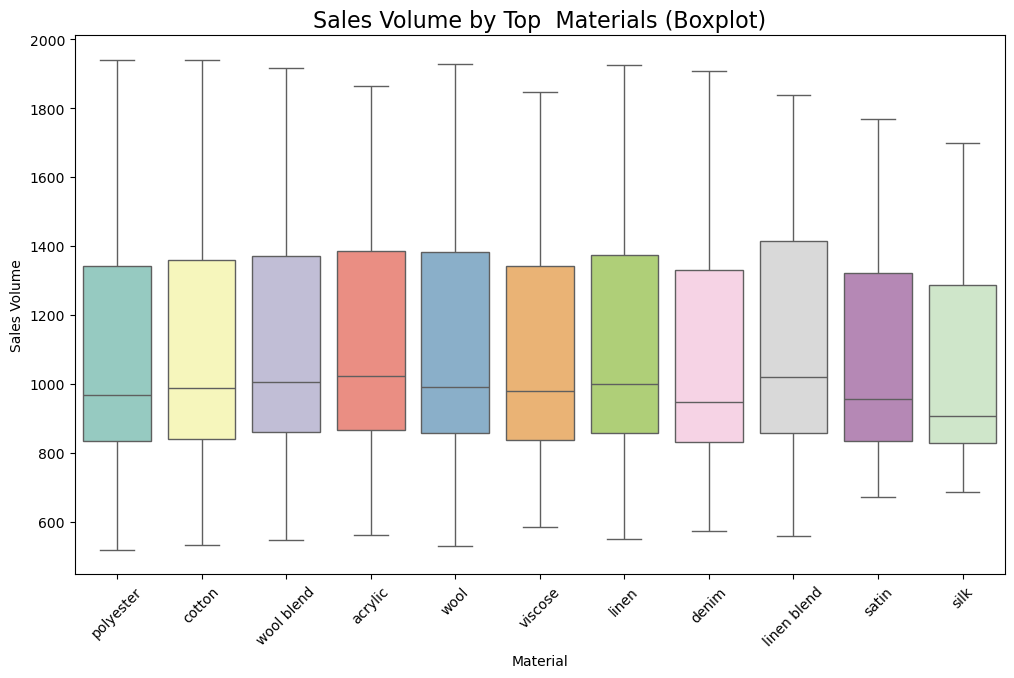

In [88]:
top_materials = df['material'].value_counts().index
data_top_mat = df[df['material'].isin(top_materials)]

plt.figure(figsize=(12, 7))
sns.boxplot(data=data_top_mat, x='material', y='Sales Volume', palette='Set3')
plt.title('Sales Volume by Top  Materials (Boxplot)', fontsize=16)
plt.xlabel('Material')
plt.ylabel('Sales Volume')
plt.xticks(rotation=45)
plt.show()

C:\Users\maham\AppData\Local\Temp\ipykernel_44612\3232074079.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




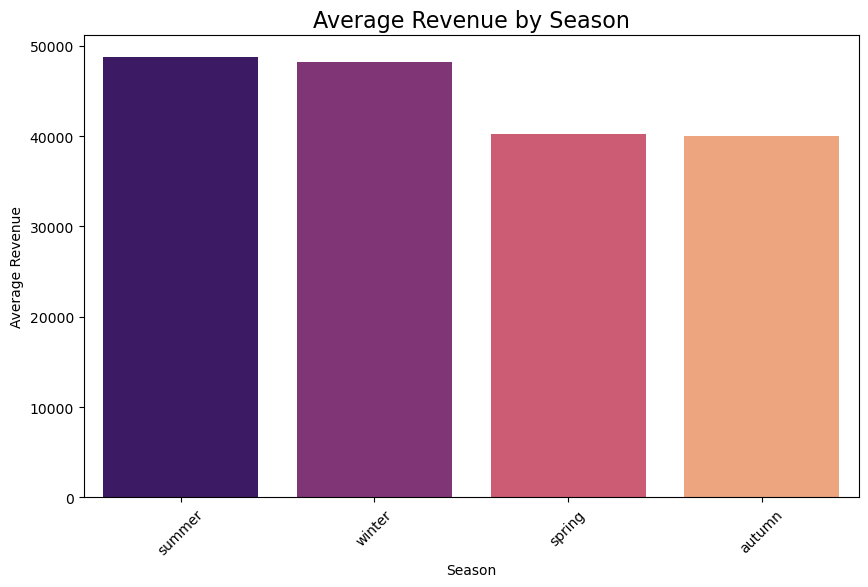

In [89]:
plt.figure(figsize=(10, 6))
season_revenue = df.groupby('season')['revenue'].mean().sort_values(ascending=False)
sns.barplot(x=season_revenue.index, y=season_revenue.values, palette='magma')
plt.title('Average Revenue by Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.show()

C:\Users\maham\AppData\Local\Temp\ipykernel_44612\416967963.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




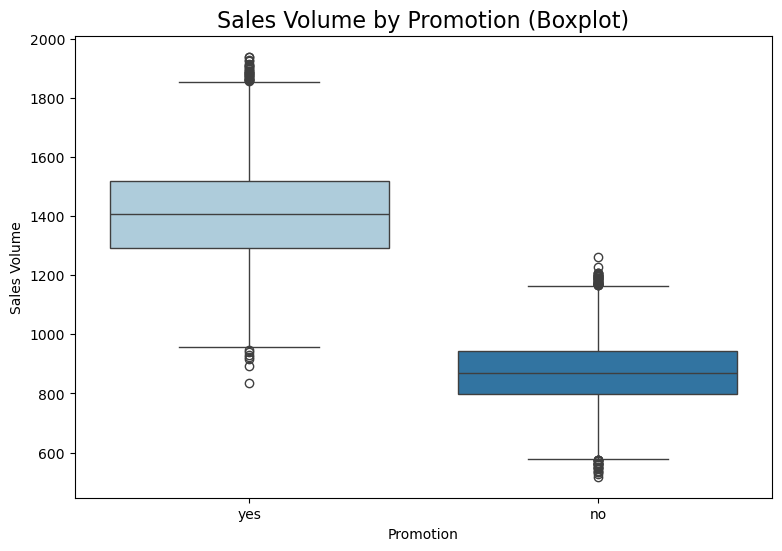

In [90]:

plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Promotion', y='Sales Volume', palette='Paired')
plt.title('Sales Volume by Promotion (Boxplot)', fontsize=16)
plt.xlabel('Promotion')
plt.ylabel('Sales Volume')
plt.show()

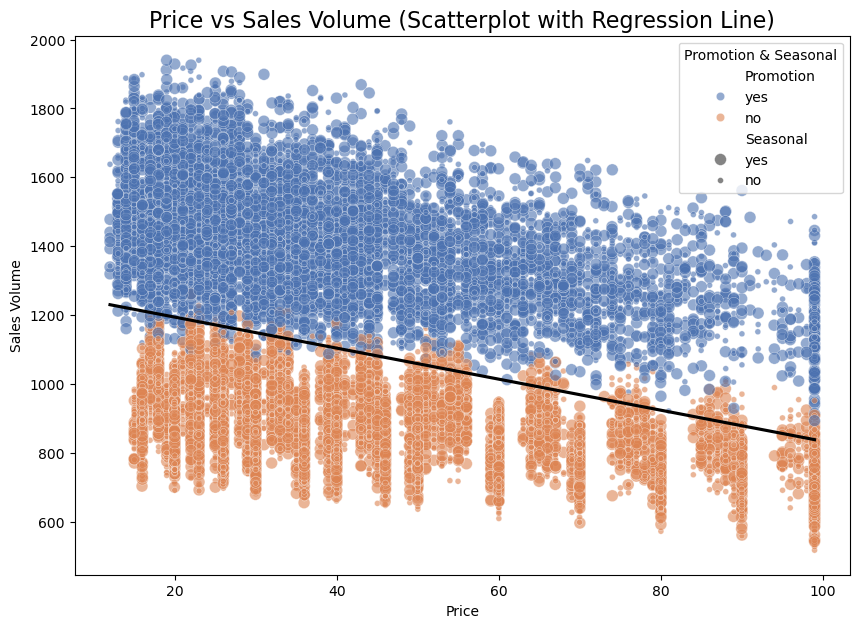

In [91]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='price', y='Sales Volume', alpha=0.6, hue='Promotion', palette='deep', size='Seasonal')
sns.regplot(data=df, x='price', y='Sales Volume', scatter=False, color='black', ci=None)
plt.title('Price vs Sales Volume (Scatterplot with Regression Line)', fontsize=16)
plt.xlabel('Price')
plt.ylabel('Sales Volume')
plt.legend(title='Promotion & Seasonal')
plt.show()

## 5. Feature Engineering

In [92]:
df['Price Category'] = pd.qcut(df['price'], q=3, labels=['cheap', 'medium', 'premium'])

print("Price Category boundaries:")
print(df['price'].describe(percentiles=[0.333, 0.666]))

Price Category boundaries:
count    20250.000000
mean        41.546795
std         22.167378
min         12.000000
33.3%       26.950000
50%         35.950000
66.6%       45.990000
max         98.950000
Name: price, dtype: float64


In [93]:

df['Demand Score'] = df['Sales Volume'].rank(pct=True) * 100

df['Demand Score'] = df['Demand Score'].round(0).astype(int)


In [94]:
print("\nDemand Score statistics:")
print(df['Demand Score'].describe())



Demand Score statistics:
count    20250.000000
mean        50.001383
std         28.872075
min          0.000000
25%         25.000000
50%         50.000000
75%         75.000000
max        100.000000
Name: Demand Score, dtype: float64


In [95]:
print(df['Promotion'].unique())


['yes' 'no']


In [96]:
df['Promotion Flag'] = (df['Promotion'].str.lower() == 'yes').astype(int)

print(df['Promotion Flag'].value_counts())

Promotion Flag
0    11810
1     8440
Name: count, dtype: int64


In [97]:
print("\nNew columns added:")
print(df[['price', 'Price Category', 'Sales Volume', 'Demand Score', 'Promotion', 'Promotion Flag']].head(10))


New columns added:
   price Price Category  Sales Volume  Demand Score Promotion  Promotion Flag
0  78.99        premium          1243            65       yes               1
1  14.99          cheap          1429            81       yes               1
2  71.95        premium          1168            61       yes               1
3  30.99         medium          1348            73       yes               1
4  22.99          cheap          1602            94       yes               1
5  25.95          cheap          1282            68       yes               1
6  87.99        premium           688             2        no               0
7  24.00          cheap          1711            98       yes               1
8  32.95         medium           857            27        no               0
9  39.95         medium           769            10        no               0


## 6. Statistical Hypothesis Testing

In [98]:
group_prom = df[df['Promotion Flag'] == 1]['Sales Volume']
group_no_prom = df[df['Promotion Flag'] == 0]['Sales Volume']

In [99]:
print("Number of products with Promotion:", len(group_prom))
print("Number of products without Promotion:", len(group_no_prom))
print("\n Average sales with Promotion:", round(group_prom.mean(), 2))
print(" Average sales without Promotion:", round(group_no_prom.mean(), 2))
print("Difference in average sales:", round(group_prom.mean() - group_no_prom.mean(), 2))

Number of products with Promotion: 8440
Number of products without Promotion: 11810

 Average sales with Promotion: 1412.33
 Average sales without Promotion: 872.39
Difference in average sales: 539.94


In [100]:
t_stat, p_value = stats.ttest_ind(
    group_prom, 
    group_no_prom, 
    equal_var=False,  
    alternative='greater' 
)

In [101]:
print("\n Test results:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (one-sided): {p_value:.6f}")


 Test results:
T-statistic: 264.1157
P-value (one-sided): 0.000000


In [102]:
alpha = 0.05
if p_value < alpha:
    insight = "p-value < 0.05 → We reject H0. There is strong statistical evidence that the promotion significantly increases sales."
else:
    insight = "p-value >= 0.05 → We cannot reject H0. There is not enough statistical evidence that the promotion has a positive effect on sales."

print("\nInsight:")
print(insight)


Insight:
p-value < 0.05 → We reject H0. There is strong statistical evidence that the promotion significantly increases sales.


In [103]:
mean_diff = group_prom.mean() - group_no_prom.mean()
pooled_std = np.sqrt((group_prom.var() + group_no_prom.var()) / 2)
cohens_d = mean_diff / pooled_std

In [104]:
print(f"nCohen's d (Effect size): {cohens_d:.3f}")
if cohens_d > 0.8:
    effect = "Very large"
elif cohens_d > 0.5:
    effect = "Medium to large"
elif cohens_d > 0.2:
    effect = "Small to medium"
else:
    effect = "Small"
print(f"Effect size: {effect}")

nCohen's d (Effect size): 3.884
Effect size: Very large


## 7. Probability Modeling - Poisson Distribution

Overall λ (expected sales count): 1097.43


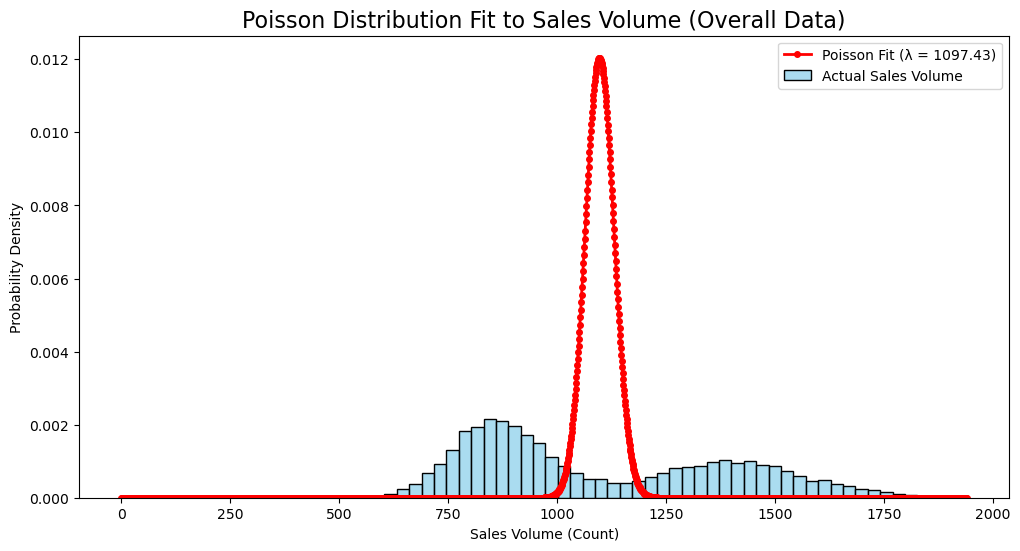

In [105]:
overall_lambda = df['Sales Volume'].mean()
print(f"Overall λ (expected sales count): {overall_lambda:.2f}")
plt.figure(figsize=(12, 6))
sns.histplot(df['Sales Volume'], bins=50, stat='density', alpha=0.7, color='skyblue', label='Actual Sales Volume')
x_overall = np.arange(0, df['Sales Volume'].max() + 1)
poisson_pmf = stats.poisson.pmf(x_overall, overall_lambda)
plt.plot(x_overall, poisson_pmf, 'r-o', lw=2, markersize=4, label=f'Poisson Fit (λ = {overall_lambda:.2f})')
plt.title('Poisson Distribution Fit to Sales Volume (Overall Data)', fontsize=16)
plt.xlabel('Sales Volume (Count)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

In [106]:
prom_lambda = df[df['Promotion Flag'] == 1]['Sales Volume'].mean()
no_prom_lambda = df[df['Promotion Flag'] == 0]['Sales Volume'].mean()

print(f"\nPromotional λ: {prom_lambda:.2f}")
print(f"Non-Promotional λ: {no_prom_lambda:.2f}")
print(f"Difference: +{prom_lambda - no_prom_lambda:.2f} ({(prom_lambda / no_prom_lambda - 1)*100:.1f}% increase)")


Promotional λ: 1412.33
Non-Promotional λ: 872.39
Difference: +539.94 (61.9% increase)


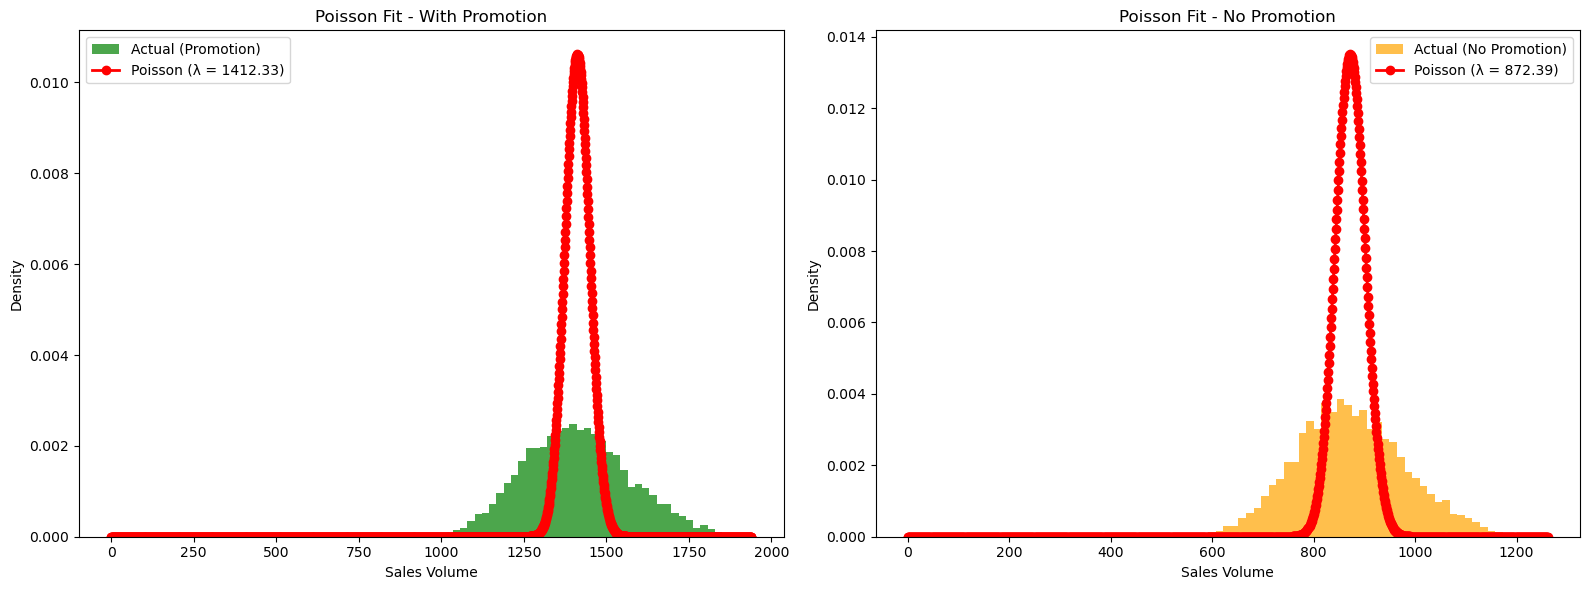

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# With Promotion
axes[0].hist(df[df['Promotion Flag'] == 1]['Sales Volume'], bins=50, density=True, alpha=0.7, color='green', label='Actual (Promotion)')
x_prom = np.arange(0, df[df['Promotion Flag'] == 1]['Sales Volume'].max() + 1)
axes[0].plot(x_prom, stats.poisson.pmf(x_prom, prom_lambda), 'r-o', lw=2, label=f'Poisson (λ = {prom_lambda:.2f})')
axes[0].set_title('Poisson Fit - With Promotion')
axes[0].set_xlabel('Sales Volume')
axes[0].set_ylabel('Density')
axes[0].legend()

# No Promotion
axes[1].hist(df[df['Promotion Flag'] == 0]['Sales Volume'], bins=50, density=True, alpha=0.7, color='orange', label='Actual (No Promotion)')
x_no = np.arange(0, df[df['Promotion Flag'] == 0]['Sales Volume'].max() + 1)
axes[1].plot(x_no, stats.poisson.pmf(x_no, no_prom_lambda), 'r-o', lw=2, label=f'Poisson (λ = {no_prom_lambda:.2f})')
axes[1].set_title('Poisson Fit - No Promotion')
axes[1].set_xlabel('Sales Volume')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

In [108]:
overall_var = df['Sales Volume'].var()
print(f"\nVariance of Sales Volume: {overall_var:.2f}")
if overall_var > overall_lambda + overall_lambda**2 / len(df):  # Rough overdispersion check
    print("Note: Variance > Mean → Possible overdispersion (Poisson may underfit tails). Consider Negative Binomial for better modeling.")
else:
    print("Variance ≈ Mean → Poisson fit looks reasonable.")



Variance of Sales Volume: 88944.82
Note: Variance > Mean → Possible overdispersion (Poisson may underfit tails). Consider Negative Binomial for better modeling.


## 8. PCA and Clustering

In [109]:
numeric_features = ['price', 'Sales Volume', 'revenue']  
categorical_features = ['season', 'Promotion Flag', 'material', 'terms', 'section']  

In [110]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'  
)

In [111]:
df_preprocessed = preprocessor.fit_transform(df)

In [112]:
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
print(f"Total features after preprocessing: {df_preprocessed.shape[1]} (numeric: 3 + one-hot: {len(cat_cols)})")


Total features after preprocessing: 22 (numeric: 3 + one-hot: 19)


In [113]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_preprocessed)

In [114]:
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

print(f"\nExplained variance ratio: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total explained variance by 2 components: {pca.explained_variance_ratio_.sum():.3f}")


Explained variance ratio: PC1=0.358, PC2=0.261
Total explained variance by 2 components: 0.618


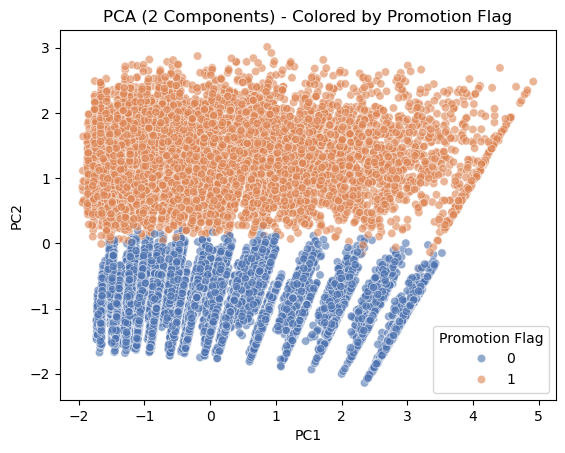

In [115]:
plt.figure()
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Promotion Flag', palette='deep', alpha=0.6)
plt.title('PCA (2 Components) - Colored by Promotion Flag')
plt.show()

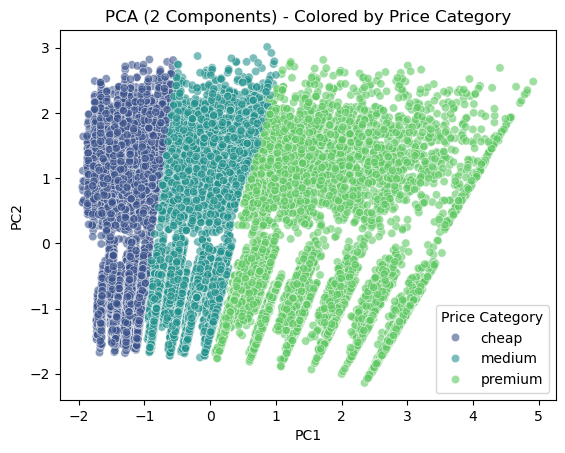

In [116]:
plt.figure()
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Price Category', palette='viridis', alpha=0.6)
plt.title('PCA (2 Components) - Colored by Price Category')
plt.show()


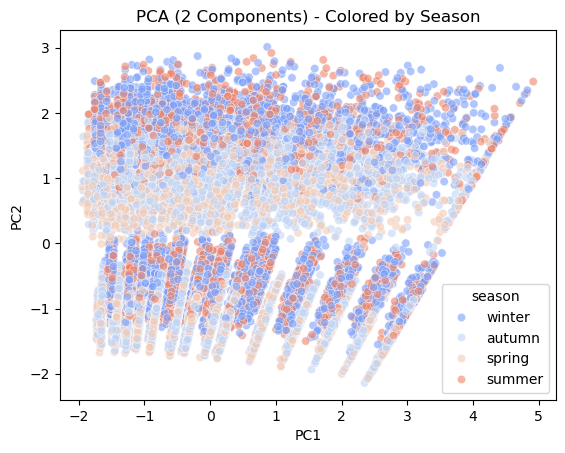

In [117]:
plt.figure()
sns.scatterplot(data=df, x='PC1', y='PC2', hue='season', palette='coolwarm', alpha=0.6)
plt.title('PCA (2 Components) - Colored by Season')
plt.show()

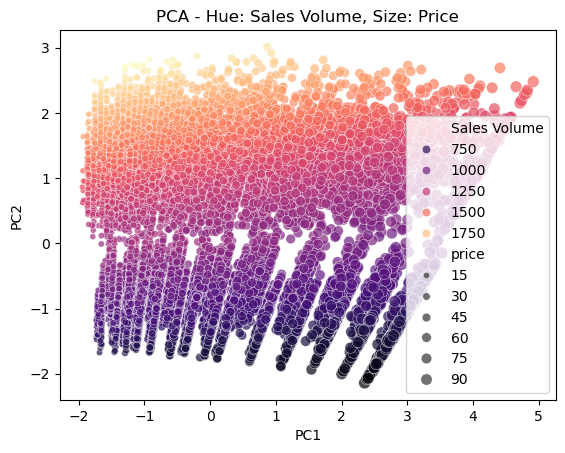

In [118]:
plt.figure()
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Sales Volume', size='price', palette='magma', alpha=0.7)
plt.title('PCA - Hue: Sales Volume, Size: Price')
plt.show()

In [119]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['PCA_Cluster'] = kmeans.fit_predict(X_pca)

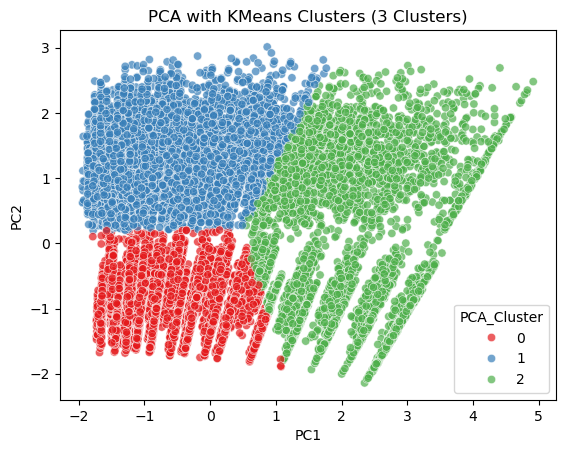

In [120]:
plt.figure()
sns.scatterplot(data=df, x='PC1', y='PC2', hue='PCA_Cluster', palette='Set1', alpha=0.7)
plt.title('PCA with KMeans Clusters (3 Clusters)')
plt.show()

In [121]:
print("\nCluster Characteristics (Mean values):")
cluster_means = df.groupby('PCA_Cluster')[['price', 'Sales Volume', 'revenue', 'Promotion Flag']].mean()
print(cluster_means)

print("\nCluster Composition - Price Category (%):")
print(pd.crosstab(df['PCA_Cluster'], df['Price Category'], normalize='index') * 100)

print("\nCluster Composition - Season (%):")
print(pd.crosstab(df['PCA_Cluster'], df['season'], normalize='index') * 100)

print("\nCluster Composition - Promotion Flag (% with Promotion):")
print(df.groupby('PCA_Cluster')['Promotion Flag'].mean() * 100)


Cluster Characteristics (Mean values):
                price  Sales Volume       revenue  Promotion Flag
PCA_Cluster                                                      
0            33.15746    895.188921  29250.079303        0.004012
1            28.65965   1452.172940  41303.441578        0.999691
2            74.65847    996.309425  72627.130146        0.401168

Cluster Composition - Price Category (%):
Price Category      cheap     medium     premium
PCA_Cluster                                     
0               38.843067  45.207312   15.949621
1               52.730639  40.975008    6.294354
2                0.000000   0.000000  100.000000

Cluster Composition - Season (%):
season          autumn     spring     summer     winter
PCA_Cluster                                            
0            40.002229  23.272403  12.984842  23.740526
1            37.935822  22.755322  14.625116  24.683740
2            33.694746  20.287740  16.534612  29.482902

Cluster Composition - Prom

In [126]:
# Add readable cluster names
cluster_names = {
    0: "Basic Products (Low Price, No Promo)",
    1: "Promotion Hits (Low Price, High Volume)",
    2: "Premium Products (High Price, High Revenue)"
}
df['Cluster Name'] = df['PCA_Cluster'].map(cluster_names)


## 9. Key Insights and Business Recommendations
### Key Insights
Promotion Effectiveness: Promotions have a dramatic impact on sales, increasing average sales volume from 872 units (without promotion) to 1,412 units (with promotion) — a 62% uplift. This effect is statistically significant (t-test p-value ≈ 0, Cohen's d = 3.88, indicating a very large effect size).
Product Segmentation: Using PCA and KMeans clustering, the data reveals three distinct product segments:
Basic Products (~50% of data): Low-to-medium price (~$33), moderate sales volume (~895), almost no promotion needed (0.4% promoted).
Promotion Hits: Low price (~$29), highest sales volume (~1,452), almost entirely driven by promotion (99.97% promoted).
Premium Products: High price (~$75), good sales volume (~996), highest revenue contribution (~$72,627 average), only partially promoted (40%).

Revenue Drivers: Despite lower volume, the Premium segment generates the highest revenue due to significantly higher prices.
Material & Seasonal Trends: Top-selling materials (wool, cotton, wool blend, polyester) account for the majority of volume. Seasonal differences in average revenue are moderate, with summer and winter slightly leading.
Demand Distribution: Sales volume follows a highly skewed distribution with overdispersion, better modeled by Negative Binomial than Poisson in advanced scenarios, but Poisson clearly shows higher expected demand (λ) under promotion.

### Business Recommendations

Aggressive Promotion on Low/Medium-Priced Products
Target "Basic Products" and similar items with frequent, high-impact promotions to convert them into "Promotion Hits," achieving proven +62% sales volume increase.
Selective Promotion for Premium Products
Avoid heavy or frequent discounts on premium items to preserve brand positioning and profit margins. Use promotions sparingly (e.g., end-of-season or exclusive events).
Prioritize Premium Segment Expansion
Invest in developing and marketing more premium products, as they deliver the highest revenue per unit and strong performance even without heavy promotion.
Segment-Based Marketing & Inventory Strategy
Tailor campaigns and stock planning to the three identified segments:
High stock + aggressive marketing for Promotion Hits during campaigns
Quality-focused branding for Premium
Steady supply for Basic Products

Continuous Monitoring via Dashboard
Use the interactive Power BI dashboard to track promotion ROI, segment performance, and seasonal trends in real-time for data-driven decisions.

## 10. Interactive Dashboard (Power BI)
An interactive dashboard was developed in Power BI to visualize the analysis results and enable dynamic exploration of the data.
Key Features:

KPIs: Total products (20.25K), total revenue ($878.48M), average sales volume (1.10K), and highlighted promotion impact (+62% statistically significant).
Slicers: Filters for Price Category, Promotion, and Season for interactive analysis.
Main Visualizations:
Average Revenue by Season (bar chart)
Sales Volume by Top Materials (horizontal bar chart)
PCA Scatter Plot: Shows clear separation of the three product clusters in reduced 2D space (colored by Cluster Name)
Price vs Sales Volume Scatter Plot: Illustrates promotion effect (promoted products achieve higher volume at lower prices)

Layout: Clean, professional design with a large title, balanced visuals, and consistent blue color scheme.
Purpose: Enables stakeholders to explore relationships, filter by segments or seasons, and quickly derive actionable insights without technical knowledge.

The dashboard effectively communicates the story: promotions drive volume in low-price items, while premium items drive revenue.
![My Plot](Dashboard.png)

## 11. Conclusion
This project successfully analyzed e-commerce sales data for over 20,000 products to uncover actionable insights for sales optimization.
Through systematic data cleaning, feature engineering, exploratory analysis, statistical testing, probability modeling, and advanced clustering, we demonstrated that:

Promotions are highly effective, delivering a statistically proven 62% increase in sales volume.
The product portfolio naturally segments into three meaningful groups with distinct price, volume, promotion dependency, and revenue characteristics.
Strategic differentiation between segments can significantly improve both sales volume and revenue.

The findings were consolidated into an interactive Power BI dashboard that allows non-technical stakeholders to explore the data and monitor key metrics dynamically.
By implementing the recommended promotion and segmentation strategies, the business can achieve higher sales volume, better margin protection, and maximized revenue — ultimately driving more efficient and profitable operations.

In [ ]:
#df.to_csv('ecommerce_sales_dashboard.csv', index=False)